In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

import numpy as np
import time
import nibabel as nib
import os
import json
from tqdm.notebook import tqdm
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

from torch.optim import Adam
from scipy.ndimage import distance_transform_edt
import time
from typing import Dict, Optional

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [2]:
print(device)

cuda


In [4]:
# mount data drive
from google.colab import drive

drive.mount('/content/drive') # mount drive


"""
"tensorImageSize": "4D",
"modality": {
	 "0": "FLAIR",
	 "1": "T1w",
	 "2": "t1gd",
	 "3": "T2w"
 },
 "labels": {
	 "0": "background",
	 "1": "edema",
	 "2": "non-enhancing tumor",
	 "3": "enhancing tumour"
 },
"""
braintumor_datadir = "/content/drive/MyDrive/data/med/braintumor"


bt_train_images_dir = os.path.join(braintumor_datadir, "train/images")
bt_train_labels_dir = os.path.join(braintumor_datadir, "train/labels")

bt_test_images_dir = os.path.join(braintumor_datadir, "test/images")
bt_test_labels_dir = os.path.join(braintumor_datadir, "test/labels")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
IMAGE_SHAPE = (1, 4, 155, 240, 240)
NUM_CLASSES = 4

In [6]:
def z_score_normalization(x: torch.tensor, eps=1e-8) -> torch.tensor:
    """
    Args:
        - x: 4D tensor of shape (channel, depth, height, width)
        - eps: float to avoid dividing by zero
    performs per-channel z-score normalization, avoids supressing signals or enforcing artificial signals
    return:
        - output: a 4D tensor of shape (channel, depth, height, width)
                    - each channel is normalized seperately and is added to its respective position in the output tensor
                    using its own mean and standard deviation
    """

    # initializing output tensor with the same shape as input tensor
    output = torch.empty_like(x)

    for c in range(x.shape[0]):
        channel = x[c] # shape (depth, width, height)

        mean = channel.mean()
        std = channel.std() + eps

        output[c] = (channel-mean) / std

    return output

# method to load .nii.gz files
def load_nib(file_path, filename):
    """
    loads .nii.gz files and returns its contents as nunpy array
    Args:
        - file_path: file path or directory of the files
        - filename: name of the file to be loaded

    return:
        - numpy format of the file
    """
    return nib.load(os.path.join(file_path, filename)).get_fdata()

def filename_set(file_path):
    """
    Args:
        file_path: file path or directory of the files

    return:
        - list of filenames that ends with .nii.gz
    """
    return {f for f in os.listdir(file_path) if f.endswith( '.nii.gz')}

In [7]:
class BratsDataset(Dataset):
    """
    creates pytorch dataset to load .nii.gz images and labels
    image and label inputs are of the foramt (height, width, depth, channel)
    image_output format: (channel, depth, height, width)
    label_output format: (classes, depth, height, width)
    """


    def __init__(self, image_dir, labels_dir, transform=None):
        """
        Args
            - image_dir: directory containing image files
            - label_dir: directory containing label files
            - transform: callable method that transforms the data
        """

        self.image_dir = image_dir # image directory
        self.label_dir = labels_dir # label directory

        # gets set of file names from image and label directories
        self.image_files = filename_set(self.image_dir)
        self.label_files = filename_set(self.label_dir)

        self.transform = transform # loads transform

        # stores intersection of file names that are in both image and label directories
        self.common_filenames = sorted(self.image_files & self.label_files)

    def __len__(self):
        # returns length of files that are common in image and label directories
        return len(self.common_filenames)


    def __getitem__(self, index):
        #  loads and returns a single sample file by applying the given transformation
        file_index = self.common_filenames[index] # indexed filename from common_filenames

        image = load_nib(self.image_dir, file_index) # loads images of .nii.gz format from images directory
        label = load_nib(self.label_dir, file_index) # loads labels of .nii.gz format from labels directory

        image_tensor = torch.from_numpy(image).float() # converts numpy format of images to float tensors
        image_tensor = image_tensor.permute(3, 2, 0, 1) # permutes (height, width, depth, channels) -> (channels, depth, height, width)

        if self.transform: # applies transformation on image_tensor
            image_tensor = self.transform(image_tensor)


        label_tensor = torch.from_numpy(label) # converts numpy format of images to long tensors
        #label_tensor = F.one_hot(label_tensor, num_classes=4) # onehot encodes the labels to 4 classes
        label_tensor = label_tensor.permute(2, 0, 1).long() # permutes (height, width, depth) -> (depth, height, width)


        return image_tensor, label_tensor # returns image and label tensor

In [8]:
# load brain tumor train and test data images and labels

bt_train_dataset = BratsDataset(bt_train_images_dir, bt_train_labels_dir, transform=z_score_normalization)
bt_test_dataset = BratsDataset(bt_test_images_dir, bt_test_labels_dir)

In [9]:
# data loader for loading files
bt_train_datalaoder = DataLoader(bt_train_dataset)

In [10]:
class NormalizedActivation(nn.Module):
    """
    normalization + activation for convolutional layers, dynamically normalizes and applies activation on output feature maps

    mu: learnable parameter, similar to mean, but not neceessarily computed in statistical manner,
            helps in shifting and centering data by adapating to channels inherent data values and spread

    alpha: learnable scale (std_dev) for normalization, passed through softplus to ensure positive values
    beta: learnable scaling quantity that can learn to scale contrasting or emphasize non-linearity based on the values
    gamma: controls threshold of non-linear transformations

    placed after convolutional layer that combines both normalization and activations

    uses 1 sample per batch
    input_shape: (batch, channel, depth, height, width), (1, C, D, H, W)
    output_shape: (batch, channel, depth, height, width), (1, C, D, H, W)
    """

    def __init__(self, channels, eps=1e-2):
        # initializes learnable parameters for each channel
        """
        Args:
            - channels: number of input channels, typically the output channels of convolutions
            - eps: small epsilon added to avoid division by zero if alpha goes to zero
        """

        super().__init__()

        self.channels = channels
        self.mu = self._learnable_paramemters()
        self.gamma = self._learnable_paramemters()
        self.beta = self._learnable_paramemters()
        self.alpha = nn.Parameter(torch.zeros(self.channels, dtype=torch.float32))
        self.eps = eps


    def _learnable_paramemters(self):
        # initializes parameters with ones
        return nn.Parameter(torch.ones(self.channels, dtype=torch.float32))


    def forward(self, x):
        """
        applies normalization to the input tensor which is the output of convolution operation

        Args:
            - x: input tensor of shape (batch, channel, depth, height, width)

        returns:
            - transformed tensor of the same shape

        """

        # target shape for broadcasting on channels
        shape = (1, -1, 1, 1, 1)

        # (1, channel, 1, 1, 1)
        mu = self.mu.view(shape)
        beta = self.beta.view(shape)
        gamma = self.gamma.view(shape)

        # applying softplus  to ensure >=0, where eps is added to avoid division by zero
        alpha = F.softplus(self.alpha.view(shape)) + self.eps

        # g(x) = x - learned_center / spread
        gx = (x - mu) / alpha


        # smooth clamping to -gamma, gamma
        gx = torch.tanh(gx/gamma) * gamma

        # applies sigmoid  squashing outputs to (0, 1)
        gx = torch.sigmoid(beta * gx)

        return gx

In [11]:

def conv_norm_act(in_channels, out_channels, kernel=3, padding=1, stride=1):

    """
    Args:
        - in_channels: number of input channels
        - out_channels: number of output channels
        - kernel: size of convolutional kernel/filter
        - padding: size of padding
        - stride: stride of convolutional filter

        peroforms 3D convolution on the input data takes input_channels,
            if stride == 1: returns the same spatial deimensional tensor
            if stride == 2: returns the tensor with half the spatial dimension

        applies normalized activation: performs normalization followed by activation

    Returns:
        - tensor of shape (1, out_channels, depth, width, height)

        ex: if stride==2, in=16, out=32
             input: (1, 16, 78, 120, 120) --conv3d-->(1, 32, 39, 60, 60)

    """

    return nn.Sequential(
        nn.Conv3d(in_channels, out_channels, kernel_size=kernel, padding=padding, stride=stride),
        NormalizedActivation(out_channels)

    )

def conv_norm_act_upsample(in_channels, out_channels, target_size, kernel=3, padding=1, stride=1):
    """
    Args:
        - in_channels: number of input channels
        - out_channels: number of output channels
        - target_size: size of the upsampled tensor
        - kernel: size of convolutional kernel/filter
        - padding: size of padding
        - stride: stride of convolutional filter


        applies upsample and reshapes the tensor to the size of target_size

        peroforms 3D convolution on the input data takes input_channels,
            if stride == 1: returns the same spatial deimensional tensor
            if stride == 2: returns the tensor wi2,th half the spatial dimension

        applies normalized activation: performs normalization followed by activation


    Returns:
        - tensor of shape (1, out_channels, depth, width, height)


        ex: input: (1, 128, 19, 30, 30), target_shape: (1, 64, 39, 60, 60)
            upsample: (1, 128, 19, 30, 30) -> (1, 128, 39, 60, 60) -- conv --> (1, 64, 39, 60, 60)

    """
    return nn.Sequential(
        nn.Upsample(size=target_size, mode='trilinear', align_corners=True),
        nn.Conv3d(in_channels, out_channels, kernel_size=kernel, padding=padding, stride=stride),
        NormalizedActivation(out_channels)
    )




In [12]:
class TverskyDiceLoss(nn.Module):
    def __init__(self, alpha=0.3, beta=0.7, eps=1e-6, reg_weight=0.1):
        super().__init__()
        self.log_alpha = nn.Parameter(torch.log(torch.tensor(alpha)))
        self.log_beta = nn.Parameter(torch.log(torch.tensor(beta)))
        self.eps = eps
        self.reg_weight = reg_weight

    def forward(self, pred, target):
        # pred: (B, C, D, H, W), probs
        # target: (B, C, D, H, W), one-hot

        dims = (2, 3, 4)

        TP = (pred * target).sum(dim=dims)
        FP = (pred * (1 - target)).sum(dim=dims)
        FN = ((1 - pred) * target).sum(dim=dims)

        alpha = torch.exp(self.log_alpha)
        beta = torch.exp(self.log_beta)

        tversky = (TP + self.eps) / (TP + alpha * FP + beta * FN + self.eps)
        loss = 1 - tversky.mean()

        reg = self.reg_weight * (alpha - beta).pow(2)
        return loss + reg


In [13]:
class CrossEntropyLoss(nn.Module):
    def __init__(self, reg_weight=0.0):
        """
        Args:
            - reg_weight: weight for regularization on class weights
        """
        super().__init__()
        self.num_classes = 4
        self.log_weights = nn.Parameter(torch.zeros(self.num_classes))  # Learnable log-weights
        self.reg_weight = reg_weight

    def forward(self, probs, target):
        """
        Args:
            - probs: predicted class probabilities (B, C, ...)
            - target: target labels (B, ...)
        Returns:
            - scalar loss value
        """
        weights = torch.exp(self.log_weights)
        weights = weights / weights.sum()  # Normalize to sum to 1

        # Compute log probabilities
        log_probs = torch.log(probs + 1e-8)

        # Use .detach() here to keep weights frozen during loss computation if needed
        loss = F.nll_loss(log_probs, target.long(), weight=weights.detach(), reduction='mean')

        # Regularize weight variance to prevent collapse
        reg = self.reg_weight * torch.var(weights) if self.reg_weight > 0 else 0.0

        return loss + reg


In [14]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class StructuralLossV3(nn.Module):
    def __init__(self, boundary_width=2):
        super().__init__()
        self.alpha = nn.Parameter(torch.tensor(1.0))  # Dice weight
        self.beta = nn.Parameter(torch.tensor(1.0))   # CE weight
        self.gamma = nn.Parameter(torch.tensor(0.1))  # Topology weight

        self.boundary_width = boundary_width

        self.dice_loss = TverskyDiceLoss()
        self.ce = CrossEntropyLoss()

        self._init_3D_sobel_filter()

    def _init_3D_sobel_filter(self):
        sobel_x = torch.tensor([
            [[1, 2, 1], [2, 4, 2], [1, 2, 1]],
            [[0, 0, 0], [0, 0, 0], [0, 0, 0]],
            [[-1, -2, -1], [-2, -4, -2], [-1, -2, -1]]
        ], dtype=torch.float32)

        sobel_y = sobel_x.permute(1, 0, 2)
        sobel_z = sobel_x.permute(2, 1, 0)

        for k in [sobel_x, sobel_y, sobel_z]:
            k /= k.abs().sum()

        self.register_buffer('sobel_x', sobel_x.view(1, 1, 3, 3, 3))
        self.register_buffer('sobel_y', sobel_y.view(1, 1, 3, 3, 3))
        self.register_buffer('sobel_z', sobel_z.view(1, 1, 3, 3, 3))

    def _compute_boundary(self, x):
        gx = F.conv3d(x, self.sobel_x, padding=1)
        gy = F.conv3d(x, self.sobel_y, padding=1)
        gz = F.conv3d(x, self.sobel_z, padding=1)

        boundary = torch.sqrt(gx ** 2 + gy ** 2 + gz ** 2 + 1e-6)
        norm = (boundary.mean(dim=(1, 2, 3, 4), keepdim=True) * 10 + 1e-6).clamp(max=1)
        return boundary / norm

    def _distance_transform_loss(self, pred_probs, target):
        pred_boundary = self._compute_boundary(pred_probs)
        target_boundary = self._compute_boundary(target)

        threshold = 0.1 * (target_boundary.max() + pred_boundary.max()).item()
        boundary_mask = ((target_boundary > threshold) | (pred_boundary > threshold)).float()

        return F.l1_loss(pred_boundary * boundary_mask, target_boundary * boundary_mask)

    def _compute_components(self, x):
        binary = (x > 0.5).float()
        maxpool = F.max_pool3d(binary, kernel_size=3, padding=1, stride=1)
        peaks = (binary * (binary == maxpool)).float()
        return peaks.view(x.size(0), -1).sum(dim=1).clamp(min=1)

    def forward(self, preds, target):
        dice_probs = F.softmax(preds, dim=1)
        dice_loss = self.dice_loss(dice_probs, target)
        ce_loss = self.ce(preds, target.long())

        topo_loss = 0.0
        for class_idx in range(dice_probs.shape[1]):
            fg_pred = dice_probs[:, class_idx:class_idx+1]
            fg_target = (target == class_idx).float().unsqueeze(1)

            if fg_target.sum() == 0:
                continue

            b_loss = self._distance_transform_loss(fg_pred, fg_target)

            pred_count = self._compute_components(fg_pred)
            target_count = self._compute_components(fg_target)
            c_loss = self._component_loss(pred_count, target_count)

            voxel_count = fg_target.sum() + 1e-5
            topo_loss += (b_loss + c_loss) / voxel_count

        total_loss = (self.alpha * dice_loss) + (self.beta * ce_loss) + (self.gamma * topo_loss)

        loss_log = {
            'total_loss': total_loss.item(),
            'dice_loss': dice_loss.item(),
            'alpha': self.alpha.item(),
            'ce_loss': ce_loss.item(),
            'beta': self.beta.item(),
            'topo_loss': topo_loss.item() if isinstance(topo_loss, torch.Tensor) else topo_loss,
            'gamma': self.gamma.item()
        }
        return total_loss, loss_log

    def _component_loss(self, pred_count, target_count):
        return F.l1_loss(pred_count, target_count)


In [15]:
def trainv0(model, train_loader, loss_fn, optimizer, num_iterations, save_dir, device='cuda'):
    os.makedirs(save_dir, exist_ok=True)

    model.to(device)
    loss_fn.to(device)

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', patience=5, factor=0.5, verbose=True
    )

    best_loss = float('inf')
    no_improve = 0
    early_stop_patience = 10

    metric_logs = []

    for step, (inputs, targets) in enumerate(train_loader):
        if step >= num_iterations:
            break

        start_time = time.time()

        model.train()
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer.zero_grad()
        preds = model(inputs)
        loss, loss_logs = loss_fn(preds, targets)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        scheduler.step(loss)

        step_time = time.time() - start_time
        current_lr = optimizer.param_groups[0]['lr']

        log_entry = {
            'step': step,
            'step_time_sec': round(step_time, 3),
            'loss': loss.item(),
            'lr': current_lr,
            **loss_logs
        }
        metric_logs.append(log_entry)

        # Save model
        checkpoint_path = os.path.join(save_dir, f'model_step{step}.pth')
        torch.save(model.state_dict(), checkpoint_path)

        # Save metrics
        with open(os.path.join(save_dir, 'metrics.json'), 'w') as f:
            json.dump(metric_logs, f, indent=2)

        # Logging to console
        ce = loss_logs.get('ce_loss', 0.0)
        dice = loss_logs.get('dice_loss', 0.0)
        topo = loss_logs.get('topo_loss', 0.0)

        print(f"[{step:04d}] {step_time:.2f}s | "
              f"Loss: {loss.item():.4f} | Dice: {dice:.4f} | CE: {ce:.4f} | Topo: {topo:.4f} | LR: {current_lr:.2e}")
    return metric_logs


In [16]:

class UNet3D(nn.Module):

    def __init__(self, in_channels=4, out_channels=[8, 16, 32, 64, 128]):
        super().__init__()


        # input_size: (1, 4, 155, 240, 240)
        self.encoder_list = nn.ModuleList([
            conv_norm_act(in_channels, out_channels[0]), # e0: (1, 4, 155, 240, 240) -> (1, 8, 155, 240, 240), skip0
            conv_norm_act(out_channels[0], out_channels[1], stride=2), # e1: (1, 8, 155, 240, 240) -> (1, 16, 78, 120, 120), skip1
            conv_norm_act(out_channels[1], out_channels[2], stride=2), # e2: (1, 16, 78, 120, 120) -> (1, 32, 39, 60, 60), skip2
            conv_norm_act(out_channels[2], out_channels[3], stride=2), # e3: (1, 32, 39, 60, 60) -> (1, 64, 20, 30, 30), skip3
            conv_norm_act(out_channels[3], out_channels[4], stride=2), # e4: (1, 64, 20, 30, 30) -> (1, 128, 10, 15, 15), skip4
        ])

        self.bottleneck = conv_norm_act(out_channels[4], out_channels[4] * 2) #bottlneck: (1, 128, 10, 15, 15) -> (1, 256, 10, 15, 15)

        self.decoder_list = nn.ModuleList([
            conv_norm_act(256, 128), # d0:(1, 256, 10, 15, 15) -> (1, 128, 10, 15, 15)
            conv_norm_act_upsample(256, 64, target_size=(20, 30, 30)), # d1: (1, 256, 10, 15, 15) -> (1, 64, 20, 30, 30)
            conv_norm_act_upsample(128, 32, target_size=(39, 60, 60)), # d2: (1, 128, 20, 30, 30) -> (1, 32, 39, 60, 60)
            conv_norm_act_upsample(64, 16, target_size=(78, 120, 120)), # d3: (1, 64, 39, 60, 60) -> (1, 16, 78, 120, 120)
            conv_norm_act_upsample(32, 8, target_size=(155, 240, 240)), # d4: (1, 32, 78, 120, 120) -> (1, 8, 155, 240, 240)
        ])

        self.final_conv = nn.Conv3d(16, 4, kernel_size=3, padding=1)


    def forward(self, x: torch.tensor):
        skips = []

        for encoder in self.encoder_list:
            """
            e0: (1, 4, 155, 240, 240) -> (1, 8, 155, 240, 240), skip0
            e1: (1, 8, 155, 240, 240) -> (1, 16, 78, 120, 120), skip1
            e2: (1, 16, 78, 120, 120) -> (1, 32, 39, 60, 60), skip2
            e3: (1, 32, 39, 60, 60) -> (1, 64, 20, 30, 30), skip3
            e4: (1, 64, 20, 30, 30) -> (1, 128, 10, 15, 15), skip4
            """
            x = encoder(x)
            skips.append(x)

        x = self.bottleneck(x) # e4, skip4 (1, 128, 10, 15, 15) -> bottleneck (1, 256, 10, 15, 15)

        skips = skips[::-1] # (skip4, skip3, skip2, skip1, skip0)


        for decoder, skip in zip(self.decoder_list, skips):
            """

            d0:(1, 256, 10, 15, 15) -> (1, 128, 10, 15, 15)
                # d0 + skip4: (1, 256, 10, 15, 15)
            d1: (1, 256, 10, 15, 15) -> (1, 64, 20, 30, 30)
                # d1 + skip3: (1, 128, 20, 30, 30)
            d2: (1, 128, 20, 30, 30) -> (1, 32, 39, 60, 60)
                # d2 + skip2: (1, 64, 39, 60, 60)
            d3: (1, 64, 39, 60, 60) -> (1, 16, 78, 120, 120)
                # d3 + skip1: (1, 32, 78, 120, 120)
            d4: (1, 32, 78, 120, 120) -> (1, 8, 155, 240, 240)
                # d4 + skip0: (1, 16, 155, 240, 240)

            """
            x = decoder(x)
            x = torch.cat([x, skip], dim=1)


        x = self.final_conv(x) # d4+skip0: (1, 16, 155, 240, 240) -> (1, 4, 155, 240, 240) final output sent to loss
        return x

In [20]:
model = UNet3D()
model = model.to(device) # Move model to device before creating the optimizer

structural_loss = StructuralLossV3()
adam_optimizer = torch.optim.Adam([
    {'params': model.parameters()},
    {'params': structural_loss.parameters()}
], lr=0.0001)

structural_loss = structural_loss.to(device) # Also move loss to device

In [21]:
trainv0(model, bt_train_datalaoder, structural_loss, adam_optimizer, 5, './checkpoint', "cuda")

[0000] 1.86s | Loss: nan | Dice: 0.9546 | CE: nan | Topo: 3.9999 | LR: 1.00e-04
[0001] 1.75s | Loss: nan | Dice: 0.9886 | CE: nan | Topo: 3.9990 | LR: 1.00e-04
[0002] 1.83s | Loss: nan | Dice: nan | CE: nan | Topo: nan | LR: 1.00e-04
[0003] 1.73s | Loss: nan | Dice: nan | CE: nan | Topo: nan | LR: 1.00e-04


KeyboardInterrupt: 

In [ ]:
# test the shape of loaded data
def inspect_data(dataset):
    for i in range(len(dataset)):
        filename = dataset.common_filenames[i]
        image, label = dataset[i]
        print(f'filename: {filename} | image_shape: {image.shape}, label_shape: {label.shape}')

In [ ]:
inspect_data(bt_train_dataset) # inspect filename, shape of images and labels


filename: BRATS_001.nii.gz | image_shape: torch.Size([4, 155, 240, 240]), label_shape: torch.Size([155, 240, 240])
filename: BRATS_002.nii.gz | image_shape: torch.Size([4, 155, 240, 240]), label_shape: torch.Size([155, 240, 240])
filename: BRATS_003.nii.gz | image_shape: torch.Size([4, 155, 240, 240]), label_shape: torch.Size([155, 240, 240])
filename: BRATS_004.nii.gz | image_shape: torch.Size([4, 155, 240, 240]), label_shape: torch.Size([155, 240, 240])
filename: BRATS_005.nii.gz | image_shape: torch.Size([4, 155, 240, 240]), label_shape: torch.Size([155, 240, 240])


In [ ]:
# insepect
for i, (image, label) in enumerate(bt_train_datalaoder):
    print(f"batch {i}, image_shape: {image.shape}, label_shape:  {label.shape}")

In [ ]:
class DiceLoss(nn.Module):

    """
    computes multi-class Dice loss for 3d segmentation
    predictions, target/ground_truth: (batch, class, depth, width, height): (1, 4, 155, 240, 240)
    """

    def __init__(self, eps=1e-4):
        super().__init__()
        self.eps = eps

    def forward(self, pred, target):
        """
        Args:
            - pred: prediction tensor of shape (1, 4, 155, 240, 240)
            - target: ground truth tensors of shape (1, 4, 155, 240, 240)

        returns:
            - dice_loss: 1 - mean dice classes
        """

        # convert targets to one-hot encoding
        if target.dim() == 4:
            target = F.one_hot(target, num_classes=4)
            target = target.permute(0, 4, 1, 2, 3).float()


        # computes numerator and denominator of dice
        intersection = (pred * target).sum(dim=(2, 3, 4))
        union = pred.sum(dim=(2, 3, 4)) + target.sum(dim=(2, 3, 4))

        # compute per-class dice score
        dice = (2 * intersection + self.eps) / (union + self.eps)

        return 1 - dice.mean()

class StructuralLossV0(nn.Module):
    def __init__(self, boundary_width=2, class_weights=None):
        super().__init__()
        self.alpha = nn.Parameter(torch.tensor(1.0))  # → exp(0)=1
        self.beta = nn.Parameter(torch.tensor(1.0))    # → exp(0)=1
        self.gamma = nn.Parameter(torch.tensor(0.1))  # → exp(-2.3)≈0.1

        self.boundary_width = boundary_width
        self.dice_loss = DiceLoss()
        self.ce = nn.CrossEntropyLoss(weight=class_weights)
        self._init_3D_sobel_filter()

    def _init_3D_sobel_filter(self):
        # Initialize and NORMALIZE SOBEL FILTERS (global L2 norm)
        sobel_x = torch.tensor([
            [[1, 2, 1], [2, 4, 2], [1, 2, 1]],
            [[0, 0, 0], [0, 0, 0], [0, 0, 0]],
            [[-1, -2, -1], [-2, -4, -2], [-1, -2, -1]]
        ], dtype=torch.float32)

        sobel_y = sobel_x.permute(1, 0, 2)
        sobel_z = sobel_x.permute(2, 1, 0)


        # Global normalization
        norm = torch.sqrt(sobel_x**2 + sobel_y**2 + sobel_z**2).sum()
        sobel_x /= norm
        sobel_y /= norm
        sobel_z /= norm

        self.register_buffer('sobel_x', sobel_x.view(1, 1, 3, 3, 3)) # for depth edges
        self.register_buffer('sobel_y', sobel_y.view(1, 1, 3, 3, 3)) # for vertical edges
        self.register_buffer('sobel_z', sobel_z.view(1, 1, 3, 3, 3)) # for horizontal edges

    def _compute_boundary(self, x):
        # Remove problematic normalization
        gx = F.conv3d(x, self.sobel_x, padding=1)
        gy = F.conv3d(x, self.sobel_y, padding=1)
        gz = F.conv3d(x, self.sobel_z, padding=1)
        return torch.sqrt(gx**2 + gy**2 + gz**2 + 1e-6)

    def _distance_transform_loss(self, pred_probs, target):
        pred_boundary = self._compute_boundary(pred_probs)
        target_boundary = self._compute_boundary(target)

        # More stable thresholding
        threshold = 0.05 * (target_boundary.max() + 1e-6)
        boundary_mask = ((target_boundary > threshold) |
                         (pred_boundary > threshold)).float()

        # PROPER boundary normalization
        diff = torch.abs(pred_boundary - target_boundary)
        return (diff * boundary_mask).sum() / (boundary_mask.sum() + 1e-6)

    def forward(self, preds, target):
        dice_preds = F.softmax(preds, dim=1)
        dice_loss = self.dice_loss(dice_preds, target)
        ce_loss = self.ce(preds, target.long())

        # Topological loss (BOUNDARY ONLY)
        topo_loss = 0.0
        for class_idx in range(dice_preds.shape[1]):
            fg_preds = dice_preds[:, class_idx].unsqueeze(1)
            target_mask = (target == class_idx).float().unsqueeze(1)
            topo_loss += self._distance_transform_loss(fg_preds, target_mask)

        # Constrained weighted sum
        total_loss = (self.alpha.exp() * dice_loss +
                      self.beta.exp() * ce_loss +
                      self.gamma.exp() * topo_loss)


        loss_log = {
            'total_loss': total_loss.item(),
            'dice_loss': dice_loss.item(),
            'alpha_dice_loss': self.alpha.item(),
            'ce_loss': ce_loss.item(),
            'beta_ce_loss': self.beta.item(),
            'topo_loss': topo_loss.item(),
            'gamma_topo_loss': self.gamma.item()

        }
        return total_loss, loss_log

In [ ]:

class StructuralLossV1(nn.Module):
    def __init__(self, boundary_width=2, class_weights=None):
        super().__init__()
        self.alpha = nn.Parameter(torch.tensor(1.0))  # → exp(0)=1
        self.beta = nn.Parameter(torch.tensor(1.0))    # → exp(0)=1
        self.gamma = nn.Parameter(torch.tensor(0.1))  # → exp(-2.3)≈0.1

        self.boundary_width = boundary_width
        self.dice_loss = DiceLoss()
        self.ce = nn.CrossEntropyLoss(weight=class_weights)
        self._init_3D_sobel_filter()

    def _init_3D_sobel_filter(self):
        # Initialize and NORMALIZE SOBEL FILTERS (global L2 norm)
        sobel_x = torch.tensor([
            [[1, 2, 1], [2, 4, 2], [1, 2, 1]],
            [[0, 0, 0], [0, 0, 0], [0, 0, 0]],
            [[-1, -2, -1], [-2, -4, -2], [-1, -2, -1]]
        ], dtype=torch.float32)

        sobel_y = sobel_x.permute(1, 0, 2)
        sobel_z = sobel_x.permute(2, 1, 0)


        sobel_x = sobel_x / sobel_x.abs().sum()
        sobel_y = sobel_y / sobel_y.abs().sum()
        sobel_z = sobel_z / sobel_z.abs().sum()


        self.register_buffer('sobel_x', sobel_x.view(1, 1, 3, 3, 3)) # for depth edges
        self.register_buffer('sobel_y', sobel_y.view(1, 1, 3, 3, 3)) # for vertical edges
        self.register_buffer('sobel_z', sobel_z.view(1, 1, 3, 3, 3)) # for horizontal edges

    def _compute_boundary(self, x):
        gx = F.conv3d(x, self.sobel_x, padding=1)
        gy = F.conv3d(x, self.sobel_y, padding=1)
        gz = F.conv3d(x, self.sobel_z, padding=1)
        return torch.sqrt(gx**2 + gy**2 + gz**2 + 1e-6)

    def _distance_transform_loss(self, pred_probs, target):
        pred_boundary = self._compute_boundary(pred_probs)
        target_boundary = self._compute_boundary(target)
        """
        threshold = 0.05 * (target_boundary.max() + 1e-6)
        boundary_mask = ((target_boundary > threshold) |
                         (pred_boundary > threshold)).float()

        diff = torch.abs(pred_boundary - target_boundary)
        return (diff * boundary_mask).sum() / (boundary_mask.sum() + 1e-6)
        """

         # Use fixed threshold instead of adaptive
        boundary_mask = ((target_boundary > 0.2) |
                         (pred_boundary > 0.2)).float()

        # Add weighting to boundary regions
        diff = torch.abs(pred_boundary - target_boundary)
        weighted_diff = diff * (1.0 + target_boundary)  # Emphasize true boundaries
        """
        print("Boundary stats:",
        pred_boundary.mean().item(),
        target_boundary.mean().item(),
        boundary_mask.mean().item())

        """

        return (weighted_diff * boundary_mask).sum() / (boundary_mask.sum() + 1e-6)


    def forward(self, preds, target):
        dice_preds = F.softmax(preds, dim=1)
        dice_loss = self.dice_loss(dice_preds, target)
        ce_loss = self.ce(preds, target.long())

        # Topological loss (BOUNDARY ONLY)
        topo_loss = 0.0
        for class_idx in range(dice_preds.shape[1]):
            fg_preds = dice_preds[:, class_idx].unsqueeze(1)
            target_mask = (target == class_idx).float().unsqueeze(1)
            topo_loss += self._distance_transform_loss(fg_preds, target_mask)

        # Constrained weighted sum
        total_loss = (self.alpha.exp() * dice_loss +
                      self.beta.exp() * ce_loss +
                      self.gamma.exp() * topo_loss)


        loss_log = {
            'total_loss': total_loss.item(),
            'dice_loss': dice_loss.item(),
            'alpha_dice_loss': self.alpha.item(),
            'ce_loss': ce_loss.item(),
            'beta_ce_loss': self.beta.item(),
            'topo_loss': topo_loss.item(),
            'gamma_topo_loss': self.gamma.item()

        }
        return total_loss, loss_log

In [ ]:
def train(model, train_loader, loss_fn, optimizer, num_iterations, save_dir, device='cuda'):
    os.makedirs(save_dir, exist_ok=True)
    model = model.to(device)
    loss_fn = loss_fn.to(device)

    # Initialize scheduler and early stopping
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', patience=5, factor=0.5, verbose=True
    )
    best_loss = float('inf')
    patience = 10
    no_improve = 0
    metric_logs = []
    best_model_path = os.path.join(save_dir, 'best_model.pth')

    for step, (inputs, targets) in enumerate(train_loader):
        if step >= num_iterations:
            break

        start_time = time.time()
        model.train()
        inputs, targets = inputs.to(device), targets.to(device) # Move inputs and targets to the device
        optimizer.zero_grad()

        output = model(inputs)
        loss, loss_logs = loss_fn(output, targets)

        # Backprop with proper gradient clipping
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()  # CRITICAL FIX: WEIGHT UPDATE

        # Update scheduler AFTER optimization
        scheduler.step(loss.item())

        # Logging
        step_time = time.time() - start_time
        step_metrics = {
            'step': step,
            'lr': optimizer.param_groups[0]['lr'],
            'step_time_sec': round(step_time, 3),
            'loss': loss.item(),
            **loss_logs
        }
        metric_logs.append(step_metrics)

        # Efficient metrics saving (append mode)
        metrics_path = os.path.join(save_dir, 'metrics.json')
        with open(metrics_path, 'a') as f:
            f.write(json.dumps(step_metrics) + '\n')  # JSONL format

        # Conditional checkpointing
        if loss.item() < best_loss:
            best_loss = loss.item()
            no_improve = 0
            torch.save(model.state_dict(), best_model_path)
        else:
            no_improve += 1

        # Periodic checkpointing (every 100 steps)
        if step % 100 == 0:
            torch.save({
                'model': model.state_dict(),
                'optimizer': optimizer.state_dict(),
                'step': step
            }, os.path.join(save_dir, f'checkpoint_step{step}.pth'))

        print(f"Step {step}: Time = {step_time:.2f}s Loss = {loss.item():.4f}, "
              f"CE = {loss_logs['ce_loss']:.4f}, Dice = {loss_logs['dice_loss']:.4f}, "
              f"Topo = {loss_logs['topo_loss']:.4f}, LR = {optimizer.param_groups[0]['lr']:.2e}")

        # Early stopping check
        if no_improve >= patience:
            print(f"Early stopping at step {step}")
            break

    # Save final model
    torch.save(model.state_dict(), os.path.join(save_dir, 'final_model.pth'))
    torch.save({
    'model': model.state_dict(),
    'optimizer': adam_optimizer.state_dict(),
    'loss': loss     # Optional, for logging/debugging
}, '/content/checkpoints1/final_model_01.pth')
    return metric_logs

In [ ]:
model = UNet3D()
model = model.to(device) # Move model to device before creating the optimizer

structural_loss = StructuralLossV1()
adam_optimizer = torch.optim.Adam([
    {'params': model.parameters()},
    {'params': structural_loss.parameters()}
], lr=0.0001)

structural_loss = structural_loss.to(device) # Also move loss to device

In [ ]:
train(model, train_loader=bt_train_datalaoder, loss_fn=structural_loss, optimizer=adam_optimizer, num_iterations=50, save_dir='./checkpoints')

In [ ]:

class UNet3D(nn.Module):

    def __init__(self, in_channels=4, out_channels=[8, 16, 32, 64, 128]):
        super().__init__()


        # input_size: (1, 4, 155, 240, 240)
        self.encoder_list = nn.ModuleList([
            conv_norm_act(in_channels, out_channels[0]), # e0: (1, 4, 155, 240, 240) -> (1, 8, 155, 240, 240), skip0
            conv_norm_act(out_channels[0], out_channels[1], stride=2), # e1: (1, 8, 155, 240, 240) -> (1, 16, 78, 120, 120), skip1
            conv_norm_act(out_channels[1], out_channels[2], stride=2), # e2: (1, 16, 78, 120, 120) -> (1, 32, 39, 60, 60), skip2
            conv_norm_act(out_channels[2], out_channels[3], stride=2), # e3: (1, 32, 39, 60, 60) -> (1, 64, 20, 30, 30), skip3
            conv_norm_act(out_channels[3], out_channels[4], stride=2), # e4: (1, 64, 20, 30, 30) -> (1, 128, 10, 15, 15), skip4
        ])

        self.bottleneck = conv_norm_act(out_channels[4], out_channels[4] * 2) #bottlneck: (1, 128, 10, 15, 15) -> (1, 256, 10, 15, 15)

        self.decoder_list = nn.ModuleList([
            conv_norm_act(256, 128), # d0:(1, 256, 10, 15, 15) -> (1, 128, 10, 15, 15)
            conv_norm_act_upsample(256, 64, target_size=(20, 30, 30)), # d1: (1, 256, 10, 15, 15) -> (1, 64, 20, 30, 30)
            conv_norm_act_upsample(128, 32, target_size=(39, 60, 60)), # d2: (1, 128, 20, 30, 30) -> (1, 32, 39, 60, 60)
            conv_norm_act_upsample(64, 16, target_size=(78, 120, 120)), # d3: (1, 64, 39, 60, 60) -> (1, 16, 78, 120, 120)
            conv_norm_act_upsample(32, 8, target_size=(155, 240, 240)), # d4: (1, 32, 78, 120, 120) -> (1, 8, 155, 240, 240)
        ])

        self.final_conv = nn.Conv3d(16, 4, kernel_size=3, padding=1)


    def forward(self, x: torch.tensor):
        skips = []

        for encoder in self.encoder_list:
            """
            e0: (1, 4, 155, 240, 240) -> (1, 8, 155, 240, 240), skip0
            e1: (1, 8, 155, 240, 240) -> (1, 16, 78, 120, 120), skip1
            e2: (1, 16, 78, 120, 120) -> (1, 32, 39, 60, 60), skip2
            e3: (1, 32, 39, 60, 60) -> (1, 64, 20, 30, 30), skip3
            e4: (1, 64, 20, 30, 30) -> (1, 128, 10, 15, 15), skip4
            """
            x = encoder(x)
            skips.append(x)

        x = self.bottleneck(x) # e4, skip4 (1, 128, 10, 15, 15) -> bottleneck (1, 256, 10, 15, 15)

        skips = skips[::-1] # (skip4, skip3, skip2, skip1, skip0)


        for decoder, skip in zip(self.decoder_list, skips):
            """

            d0:(1, 256, 10, 15, 15) -> (1, 128, 10, 15, 15)
                # d0 + skip4: (1, 256, 10, 15, 15)
            d1: (1, 256, 10, 15, 15) -> (1, 64, 20, 30, 30)
                # d1 + skip3: (1, 128, 20, 30, 30)
            d2: (1, 128, 20, 30, 30) -> (1, 32, 39, 60, 60)
                # d2 + skip2: (1, 64, 39, 60, 60)
            d3: (1, 64, 39, 60, 60) -> (1, 16, 78, 120, 120)
                # d3 + skip1: (1, 32, 78, 120, 120)
            d4: (1, 32, 78, 120, 120) -> (1, 8, 155, 240, 240)
                # d4 + skip0: (1, 16, 155, 240, 240)

            """
            x = decoder(x)
            x = torch.cat([x, skip], dim=1)


        x = self.final_conv(x) # d4+skip0: (1, 16, 155, 240, 240) -> (1, 4, 155, 240, 240) final output sent to loss
        return x

In [ ]:
class DiceLoss(nn.Module):

    """
    computes multi-class Dice loss for 3d segmentation
    predictions, target/ground_truth: (batch, class, depth, width, height): (1, 4, 155, 240, 240)
    """

    def __init__(self, eps=1e-4):
        super().__init__()
        self.eps = eps

    def forward(self, pred, target):
        """
        Args:
            - pred: prediction tensor of shape (1, 4, 155, 240, 240)
            - target: ground truth tensors of shape (1, 4, 155, 240, 240)

        returns:
            - dice_loss: 1 - mean dice classes
        """

        # convert targets to one-hot encoding
        if target.dim() == 4:
            target = F.one_hot(target, num_classes=4)
            target = target.permute(0, 4, 1, 2, 3).float()


        # computes numerator and denominator of dice
        intersection = (pred * target).sum(dim=(2, 3, 4))
        union = pred.sum(dim=(2, 3, 4)) + target.sum(dim=(2, 3, 4))

        # compute per-class dice score
        dice = (2 * intersection + self.eps) / (union + self.eps)

        return 1 - dice.mean()

In [ ]:
class StructuralLoss(nn.Module):

    """
    a segmentation loss that combines voxel-based, region-specific, and topological structures into a
    unified differentiable loss. this is from the assumption that all losses aren't equally important, thus
    enforcing learnable losses so that the model can learn and adapt the loss that also uses/preserves
    structural components that persist

    main_components:
        - dice_loss: captures regional overlap and matching
        - cross_entropy: handles per-voxel classification accuracy
        - topological: boundary loss and component count penalities

        the loss is weighed respectively by alpha, beta, and gamma which are learnable parameters
        respectively for dice, cross_entropoy, and topological loss
    """

    def __init__(self, boundary_width=2, class_weights=None):
        super().__init__()
        # learnable loss weights alpha, beta, gamma for dice, cross entropy, topology
        #self.loss_weights = nn.Parameter(torch.tensor([1.0, 1.0, 1.0])) # alpha, beta, gamma
        self.alpha = nn.Parameter(torch.tensor(1.0))  # Dice weight
        self.beta = nn.Parameter(torch.tensor(1.0))   # CE weight
        self.gamma = nn.Parameter(torch.tensor(0.1))

        self.boundary_width= boundary_width

        self.dice_loss = DiceLoss()
        self.ce = nn.CrossEntropyLoss()

        self._init_3D_sobel_filter()

    def _init_3D_sobel_filter(self):
        """
        initializes 3D sobel filter (x, y, z) for volumetric edge detection

        - create based 3D sobel filter for z axis
        - generate rotated versions for y and x axis using permute
        """

        # 3d-seobel filter for depth edge detection stacked across depth slices
        sobel_x = torch.tensor([
            [[1, 2, 1], [2, 4, 2], [1, 2, 1]], # top-slide
            [[0, 0, 0], [0, 0, 0], [0, 0, 0]], # middle-slide
            [[-1, -2, -1], [-2, -4, -2], [-1, -2, -1]] # bottom-slice
        ], dtype=torch.float32)

        # y-directional kernel by rotating axis (D, H, W) -> (H, D, W)
        sobel_y = sobel_x.permute(1, 0, 2)

        # z-directional kernel by rotating axis (D, H, W) -> (W, H, D)
        sobel_z = sobel_x.permute(2, 1, 0)

        # normalize each kernel with sum of absolute values = 1
        for k in [sobel_x, sobel_y, sobel_z]:
            k /= k.abs().sum()


        # reshape kernel to out_channels, in_channels=1, d, h, w =3
        # register_buffer: not updated during training, fixes filters, makes it part of model_states, can be saved and loaded
        self.register_buffer('sobel_x', sobel_x.view(1, 1, 3, 3, 3)) # for depth edges
        self.register_buffer('sobel_y', sobel_y.view(1, 1, 3, 3, 3)) # for vertical edges
        self.register_buffer('sobel_z', sobel_z.view(1, 1, 3, 3, 3)) # for horizontal edges


    def _compute_boundary(self, x):
        """
        applies 3D sobel filters and generates edge magnitude maps for volumetric data

        Args:
            - x: tensor of shape (batch, channel, depth, height, width): (1, 1, D, H, W)

        returns:
            - normalized gradient magnitude [0, 1] per voxel
        """
        # applies 3d convolution between x and sobel filters, padding =1 ensures sizes remain same
        gx = F.conv3d(x, self.sobel_x, padding=1)
        gy = F.conv3d(x, self.sobel_y, padding=1)
        gz = F.conv3d(x, self.sobel_z, padding=1)


        # compute gradient magnitude at each voxel in x, y, z directions, using L2 norm here
        boundary = torch.sqrt(gx**2 + gy**2 + gz**2 + 1e-6) # 1e-6 to prevent numerical instability
        """
        normalize the gradient magnitude to reduce the effect of exteme values
        computes mean edge magnitude per sample across the volume,
        scales the denominator to prevent everything from being close to 1,
         ensures values arent divided by zero in rare cases if they ever occur
        """
        boundary = boundary / (boundary.mean(dim=(1, 2, 3, 4), keepdim=True) * 10 + 1e-6).clamp(max=1)

        return boundary


    def _distance_transform_loss(self, pred_probs, target):
        """
        penalizes boundary boundary deviations, by measuring L1 distance from predictions and ground truths
        focuses on boundary voxels and complements voxel and overlap or space loss computed by cross entropy and dice
        forces explict boundary adherence where regions must be topologically constrained

        Args:
            - pred_probs: probability output map
            - targets: target labels

        returns:
            - L1 loss between preidctions and ground truth boundaries
        """


        """

        # convert probabilities to binary mask
        pred_binary = (pred_probs > 0.5).float()

        # convert ground truth to targets to binary floats
        target_binary = target.float()

        # computes distance map from binary prediction masks
        pred_dt = torch.tensor(distance_transform_edt(pred_binary.cpu().numpy()), device=pred_probs.device)

         # computes distance map from binary ground truths
        target_dt = torch.tensor(distance_transform_edt(target_binary.cpu().numpy()), device=target.device)

        # boundary mask\: have distances for both ground truth and predicted ones,
        # calculate the distance from both where we see how far are the values and
        # narrow band highlights regions which are in the same boundary width
        boundary_mask = ((target_dt < self.boundary_width)  | (pred_dt < self.boundary_width)).float()


        # computes L1 difference in distance maps
        return F.l1_loss(pred_dt * boundary_mask, target_dt*boundary_mask)

        pred_boundary = self._compute_boundary(pred_probs)
        target_boundary = self._compute_boundary(target)

        boundary_mask = (target_boundary > 0.1) | (pred_boundary > 0.1)
        boundary_mask = boundary_mask.float()


        return F.l1_loss(pred_boundary * boundary_mask, target_boundary * boundary_mask)

        """
        pred_boundary = self._compute_boundary(pred_probs)
        target_boundary = self._compute_boundary(target)

        boundary_threshold = 0.1 * (target_boundary.max() + pred_boundary.max())
        boundary_mask = ((target_boundary > boundary_threshold) |  (pred_boundary > boundary_threshold)).float()
        return F.l1_loss(pred_boundary * boundary_mask, target_boundary * boundary_mask)



    def _compute_components(self, x):
        """
        fast approximation to count how many seperate components exist in 3D volunme

        ex: if there is one tumor, then the prediction must predict one blob, where multiple compoents must be penalized
        Args:
            - x: tensor with binary volumetric values

        returns:
            - number of approximate connected components
        """

        binary = (x > 0.5).float().unsqueeze(1) # (1, 1, D, H, W)

        # max pooling over a 3d neighborhood
        maxpool = F.max_pool3d(binary, kernel_size=3, padding=1, stride=1)

        # identifies local peaks, voxels that are equal to local max and filters out redundent activations
        #peaks =( binary * (binary == maxpool)).squeeze(1)

        # counts number of peaks
       # return peaks.view(x.size(0), -1).sum(dim=1)
        components = (binary - maxpool).sum(dim=(1, 2, 3, 4))
        return components.clamp(min=1)

    def _component_loss(self, pred_count, target_count):
        """
        Args:
            - pred_count: tensor of predicted components
            - target_count: tensor of target components
        returns:
            - l1 loss over component count difference
        """

        return F.l1_loss(pred_count, target_count)
    def forward(self, preds, target):
        """
        Args:
            - preds: raw_logits (1, classes, depth, width, height): (1, 4, 155, 240, 240)
            - targets: ground truth labels (1, classes, depth, width, height): (1, 4, 155, 240, 240)

        returns:
            - total_loss: weighed sum of loss terms
            - loss_dict: breakdown of individual components
        """

        #weights = F.softmax(self.loss_weights, dim=0) # alpha, beta, gamma
       # alpha, beta, gamma = weights




        # softmax the model predictions for DICE
        dice_preds = F.softmax(preds, dim=1)
        dice_loss = self.dice_loss(dice_preds, target)


        # cross-entropy: raw logits + index labels
        ce_loss = self.ce(preds, target.long())


        # topological_loss
        """
        topo_loss = 0.0
        for class_idx in range(dice_preds.shape[1]):
            fg_preds = dice_preds[:, class_idx].unsqueeze(1)
            target_mask = (target == class_idx).float().unsqueeze(1)
            if target_mask.sum() == 0:
                continue

            boundary_loss = self._distance_transform_loss(fg_preds, target_mask)

            component_loss = self._component_loss(
                self._compute_components(fg_preds), self._compute_components(target_mask)
            )
            total_voxels = target.numel()   # number of voxels
            normalized_topo = (boundary_loss + component_loss) /( total_voxels + 1e-5)
            topo_loss += normalized_topo
            """

        topo_loss = 0.0
        for class_idx in range(dice_preds.shape[1]):
            fg_preds = dice_preds[:, class_idx].unsqueeze(1)
            target_mask = (target == class_idx).float().unsqueeze(1)
            if target_mask.sum() == 0:
                continue

            boundary_loss = self._distance_transform_loss(fg_preds, target_mask)
            pred_components = self._compute_components(fg_preds)
            target_components = self._compute_components(target_mask)
            component_loss = F.l1_loss(pred_components, target_components)

            # Normalize by foreground voxels instead of total voxels
            foreground_voxels = target_mask.sum() + 1e-5
            topo_loss += (boundary_loss + component_loss) / foreground_voxels

        total_loss = (self.alpha * dice_loss) + (self.beta * ce_loss) + (self.gamma * topo_loss)

        loss_log = {
            'total_loss': total_loss.item(),
            'dice_loss': dice_loss.item(),
            'alpha_dice_loss': self.alpha.item(),
            'ce_loss': ce_loss.item(),
            'beta_ce_loss': self.beta.item(),
            'topo_loss': topo_loss.item(),
            'gamma_topo_loss': self.gamma.item()

        }
        return total_loss, loss_log

In [ ]:
class StructuralLossV2(nn.Module):
    """
    A segmentation loss combining voxel-based, region-specific, and topological structures.
    Uses learnable weights (alpha, beta, gamma) for Dice, CE, and topological components.
    """

    def __init__(self, boundary_width=2, class_weights=None):
        super().__init__()
        # Learnable loss weights
        self.alpha = nn.Parameter(torch.tensor(1.0))  # Dice weight
        self.beta = nn.Parameter(torch.tensor(1.0))   # CE weight
        self.gamma = nn.Parameter(torch.tensor(0.1))  # Topo weight (initialized small)

        self.boundary_width = boundary_width
        self.dice_loss = DiceLoss()
        self.ce = nn.CrossEntropyLoss()
        self._init_3D_sobel_filter()

    def _init_3D_sobel_filter(self):
        """Initialize 3D Sobel filters for edge detection."""
        sobel_x = torch.tensor([
            [[1, 2, 1], [2, 4, 2], [1, 2, 1]],
            [[0, 0, 0], [0, 0, 0], [0, 0, 0]],
            [[-1, -2, -1], [-2, -4, -2], [-1, -2, -1]]
        ], dtype=torch.float32)

        sobel_y = sobel_x.permute(1, 0, 2)
        sobel_z = sobel_x.permute(2, 1, 0)

        # Normalize kernels
        for k in [sobel_x, sobel_y, sobel_z]:
            k /= k.abs().sum()

        # Register buffers
        self.register_buffer('sobel_x', sobel_x.view(1, 1, 3, 3, 3))
        self.register_buffer('sobel_y', sobel_y.view(1, 1, 3, 3, 3))
        self.register_buffer('sobel_z', sobel_z.view(1, 1, 3, 3, 3))

    def _compute_boundary(self, x):
        """Compute normalized edge magnitude maps using 3D Sobel filters."""
        gx = F.conv3d(x, self.sobel_x, padding=1)
        gy = F.conv3d(x, self.sobel_y, padding=1)
        gz = F.conv3d(x, self.sobel_z, padding=1)

        boundary = torch.sqrt(gx**2 + gy**2 + gz**2 + 1e-6)
        return boundary / (boundary.mean(dim=(1, 2, 3, 4), keepdim=True) * 10 + 1e-6).clamp(max=1)

    def _distance_transform_loss(self, pred_probs, target):
        """Differentiable boundary loss using adaptive thresholding."""
        pred_boundary = self._compute_boundary(pred_probs)
        target_boundary = self._compute_boundary(target)

        # Adaptive threshold based on image content
        boundary_threshold = 0.1 * (target_boundary.max() + pred_boundary.max())
        boundary_mask = ((target_boundary > boundary_threshold) |
                        (pred_boundary > boundary_threshold)).float()

        return F.l1_loss(pred_boundary * boundary_mask, target_boundary * boundary_mask)

    def _compute_components(self, x):
        """Differentiable approximation of connected components count in 3D volumes.
        Args:
            x: Input tensor of shape (batch_size, 1, depth, height, width)
        Returns:
            Tensor of shape (batch_size,) containing component counts
        """
        binary = (x > 0.5).float()  # Already in (B, 1, D, H, W) format

        # Max pooling to identify local maxima (centers of components)
        maxpool = F.max_pool3d(binary,
                            kernel_size=3,
                            padding=1,
                            stride=1)

        # Peaks are locations where original value equals maxpooled value
        peaks = (binary * (binary == maxpool))

        # Sum across spatial dimensions to count components
        components = peaks.view(x.size(0), -1).sum(dim=1)

        return components.clamp(min=1)  # Ensure at least 1 component exists

    def forward(self, preds, target):
        # Compute base losses
        dice_preds = F.softmax(preds, dim=1)
        dice_loss = self.dice_loss(dice_preds, target)
        ce_loss = self.ce(preds, target.long())

        # Topological loss
        topo_loss = 0.0
        for class_idx in range(dice_preds.shape[1]):
            fg_preds = dice_preds[:, class_idx].unsqueeze(1)
            target_mask = (target == class_idx).float().unsqueeze(1)

            if target_mask.sum() == 0:
                continue

            boundary_loss = self._distance_transform_loss(fg_preds, target_mask)
            pred_components = self._compute_components(fg_preds)
            target_components = self._compute_components(target_mask)
            component_loss = F.l1_loss(pred_components, target_components)

            # Normalize by foreground voxels
            foreground_voxels = target_mask.sum() + 1e-5
            topo_loss += (boundary_loss + component_loss) / foreground_voxels

        # Weighted total loss
        total_loss = (self.alpha * dice_loss) + (self.beta * ce_loss) + (self.gamma * topo_loss)

        return total_loss, {
            'total_loss': total_loss.item(),
            'dice_loss': dice_loss.item(),
            'alpha_dice_loss': self.alpha.item(),
            'ce_loss': ce_loss.item(),
            'beta_ce_loss': self.beta.item(),
            'topo_loss': topo_loss.item(),
            'gamma_topo_loss': self.gamma.item()
        }

In [ ]:
import torch
from torch import nn
import torch.nn.functional as F
import numpy as np
from scipy.ndimage import distance_transform_edt

# Assuming DiceLoss and StructuralLoss are already defined as you've written above.

# Set seed for reproducibility
torch.manual_seed(0)

# Fake input setup
batch_size = 1
num_classes = 4
depth, height, width = 16, 32, 32  # Smaller size for test speed

# Random predictions (logits)
preds = torch.randn(batch_size, num_classes, depth, height, width)

# Random target labels: integers from 0 to num_classes-1
target = torch.randint(low=0, high=num_classes, size=(batch_size, depth, height, width))

# Initialize loss function
loss_fn = StructuralLossV2(boundary_width=2)

# Run the loss function
total_loss, loss_dict = loss_fn(preds, target)

# Print results
print(f"Total Loss: {total_loss.item():.4f}")
for k, v in loss_dict.items():
    print(f"{k}: {v:.4f}")


In [ ]:
def train(model, train_loader, loss_fn, optimizer, num_iterations, save_dir, device='cuda'):

    """
    trains the model for given num_iterations with 1 sample per batch at a time
    logs and saves model's metrics at each stage
    supports conditional model reload, can be used if model degrades
    Args:
        - model: model to be trained on
        - loss_fn: customized loss function returns loss and loss metrics
        - optimizer: optimizer to update model's parameters
        - num_iterations: number of training steps to run
        - save_dir: directory to which the model's metrics are saved
        - device: cuda, else cpu if cuda is not available
    """

    os.makedirs(save_dir, exist_ok=True)
    model = model.to(device)
    loss_fn = loss_fn.to(device)

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer,
                                                          mode='min',
                                                          patience=5,
                                                          factor=0.5,
                                                          verbose=True)
    metric_logs = []

    for step, (inputs, targets) in enumerate(train_loader):
        if step >= num_iterations:
            break

        start_time = time.time()
        model.train() # sets model to training mode

        # moves data to device
        inputs = inputs.to(device)
        targets = targets.to(device)

        # zero out gradients
        optimizer.zero_grad()

        output = model(inputs) # forward pass
        loss, loss_logs = loss_fn(output, targets) # compute loss and store loss componets


        # backprop and update
        loss.backward()

        ###### debgugging check topological loss gradients (every 5 steps)
        if step % 5 == 0:
            with torch.no_grad():
                # Get gradients of topo_loss w.r.t. predictions
                topo_grad = torch.autograd.grad(
                    loss_logs['topo_loss'], output, retain_graph=True
                )[0].norm().item()
                print(f"Step {step}: Topo grad norm = {topo_grad:.6f}")

        # visualize boundaries (first step and every 10 steps)
        if step == 0 or step % 10 == 0:
            pred_probs = F.softmax(output, dim=1)  # (1, C, D, H, W)
            pred_boundary = loss_fn._compute_boundary(pred_probs[:, 0:1])  # Class 0
            plt.figure(figsize=(10, 5))
            plt.subplot(1, 2, 1)
            plt.imshow(pred_boundary[0, 0, :, :, 120].detach().cpu().numpy(), cmap='jet')  # Mid-slice (depth=120)
            plt.title(f"Step {step}: Pred Boundary (Class 0)")
            plt.colorbar()

            target_boundary = loss_fn._compute_boundary((target == 0).float().unsqueeze(1))
            plt.subplot(1, 2, 2)
            plt.imshow(target_boundary[0, 0, :, :, 120].detach().cpu().numpy(), cmap='jet')
            plt.title("Target Boundary (Class 0)")
            plt.colorbar()

            plt.savefig(os.path.join(save_dir, f"boundary_step{step}.png"))
            plt.close()
        ###########################################
        optimizer.step()
        scheduler.step(loss)

        step_time = time.time() - start_time
        # step metrics
        step_metrics = {
            'step': step,
            'step_time_sec': round(step_time, 3),
            'loss': loss.item(),
            **loss_logs
        }

        metric_logs.append(step_metrics)

        # save models metrics
        torch.save(model.state_dict(), os.path.join(save_dir, f'model_step{step}.pth'))

        # save model metrics to json, overwritten each step
        with open(os.path.join(save_dir, 'metrics.json'), 'w') as f:
            json.dump(metric_logs, f, indent=2)

        # print quick summary
        print(
            f"Step {step}: ",
            f"Time = {step_time:.2f}s"
            f"Loss = {loss.item():.4f}, "
            f"CE = {loss_logs['ce_loss']:.4f}, "
            f"Dice = {loss_logs['dice_loss']:.4f}, "
            f"Topo = {loss_logs['topo_loss']:.4f}"
        )

    return metric_logs

In [ ]:
def plot_prediction_overlay(image, gt_mask, pred_mask, slice_idx=None):
    """
    image: 3D image tensor (C, H, W) or (H, W)
    gt_mask, pred_mask: 2D masks (H, W)
    slice_idx: optional, which slice to visualize if 3D
    """
    import matplotlib.pyplot as plt
    import numpy as np

    if image.ndim == 3:
        image = image[0]  # take the first channel
    if slice_idx is not None:
        image = image[slice_idx]
        gt_mask = gt_mask[slice_idx]
        pred_mask = pred_mask[slice_idx]

    fig, axs = plt.subplots(1, 3, figsize=(12, 4))

    axs[0].imshow(image, cmap='gray')
    axs[0].imshow(gt_mask, alpha=0.4, cmap='Greens')
    axs[0].set_title("GT Overlay")

    axs[1].imshow(image, cmap='gray')
    axs[1].imshow(pred_mask, alpha=0.4, cmap='Reds')
    axs[1].set_title("Prediction Overlay")

    axs[2].imshow(np.abs(gt_mask - pred_mask), cmap='hot')
    axs[2].set_title("Difference")

    for ax in axs:
        ax.axis('off')
    plt.tight_layout()
    plt.show()


In [ ]:
def trainv3(model, train_loader, loss_fn, optimizer, num_iterations, save_dir, device='cuda'):
    os.makedirs(save_dir, exist_ok=True)
    model = model.to(device)
    loss_fn = loss_fn.to(device)

    # Initialize scheduler and early stopping
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=5, factor=0.5, verbose=True)
    best_loss = float('inf')
    patience = 10
    no_improve = 0

    metric_logs = []

    for step, (inputs, targets) in enumerate(train_loader):
        if step >= num_iterations:
            break

        start_time = time.time()
        model.train()
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()

        output = model(inputs)
        loss, loss_logs = loss_fn(output, targets)

        # Backprop and gradient clipping
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step(loss)

        # Logging
        step_time = time.time() - start_time
        step_metrics = {
            'step': step,
            'lr': optimizer.param_groups[0]['lr'],
            'step_time_sec': round(step_time, 3),
            'loss': loss.item(),
            **loss_logs
        }
        metric_logs.append(step_metrics)

        # Save checkpoints and metrics
        torch.save(model.state_dict(), os.path.join(save_dir, f'model_step{step}.pth'))
        with open(os.path.join(save_dir, 'metrics.json'), 'w') as f:
            json.dump(metric_logs, f, indent=2)

        print(f"Step {step}: Time = {step_time:.2f}s Loss = {loss.item():.4f}, "
              f"CE = {loss_logs['ce_loss']:.4f}, Dice = {loss_logs['dice_loss']:.4f}, "
              f"Topo = {loss_logs['topo_loss']:.4f}, LR = {optimizer.param_groups[0]['lr']:.2e}")

    return metric_logs

In [ ]:
model = UNet3D()
structural_loss = StructuralLossV2()
adam_optimizer = Adam(model.parameters(), lr=1e-4)


In [ ]:
trainv2(model, train_loader=bt_train_datalaoder, loss_fn=structural_loss, optimizer=adam_optimizer, num_iterations=50, save_dir='./checkpoints')

In [ ]:
class StructuralLossV2(nn.Module):
    def __init__(self, boundary_width=2, class_weights=None):
        super().__init__()
        self.alpha = nn.Parameter(torch.tensor(0.0))  # → exp(0)=1
        self.beta = nn.Parameter(torch.tensor(0.0))    # → exp(0)=1
        self.gamma = nn.Parameter(torch.tensor(-2.3))  # → exp(-2.3)≈0.1

        self.boundary_width = boundary_width
        self.dice_loss = DiceLoss()
        self.ce = nn.CrossEntropyLoss(weight=class_weights)
        self._init_3D_sobel_filter()

    def _init_3D_sobel_filter(self):
        # Initialize and NORMALIZE SOBEL FILTERS (global L2 norm)
        sobel_x = torch.tensor([
            [[1, 2, 1], [2, 4, 2], [1, 2, 1]],
            [[0, 0, 0], [0, 0, 0], [0, 0, 0]],
            [[-1, -2, -1], [-2, -4, -2], [-1, -2, -1]]
        ], dtype=torch.float32)

        sobel_y = sobel_x.permute(1, 0, 2)
        sobel_z = sobel_x.permute(2, 1, 0)


        # Global normalization
        norm = torch.sqrt(sobel_x**2 + sobel_y**2 + sobel_z**2).sum()
        sobel_x /= norm
        sobel_y /= norm
        sobel_z /= norm

        self.register_buffer('sobel_x', sobel_x.view(1,1,3,3,3))
        # ... same for y/z

    def _compute_boundary(self, x):
        # Remove problematic normalization
        gx = F.conv3d(x, self.sobel_x, padding=1)
        gy = F.conv3d(x, self.sobel_y, padding=1)
        gz = F.conv3d(x, self.sobel_z, padding=1)
        return torch.sqrt(gx**2 + gy**2 + gz**2 + 1e-6)

    def _distance_transform_loss(self, pred_probs, target):
        pred_boundary = self._compute_boundary(pred_probs)
        target_boundary = self._compute_boundary(target)

        # More stable thresholding
        threshold = 0.05 * (target_boundary.max() + 1e-6)
        boundary_mask = ((target_boundary > threshold) |
                         (pred_boundary > threshold)).float()

        # PROPER boundary normalization
        diff = torch.abs(pred_boundary - target_boundary)
        return (diff * boundary_mask).sum() / (boundary_mask.sum() + 1e-6)

    def forward(self, preds, target):
        dice_preds = F.softmax(preds, dim=1)
        dice_loss = self.dice_loss(dice_preds, target)
        ce_loss = self.ce(preds, target.long())

        # Topological loss (BOUNDARY ONLY)
        topo_loss = 0.0
        for class_idx in range(dice_preds.shape[1]):
            fg_preds = dice_preds[:, class_idx].unsqueeze(1)
            target_mask = (target == class_idx).float().unsqueeze(1)
            topo_loss += self._distance_transform_loss(fg_preds, target_mask)

        # Constrained weighted sum
        total_loss = (self.alpha.exp() * dice_loss +
                      self.beta.exp() * ce_loss +
                      self.gamma.exp() * topo_loss)


        loss_log = {
            'total_loss': total_loss.item(),
            'dice_loss': dice_loss.item(),
            'alpha_dice_loss': self.alpha.item(),
            'ce_loss': ce_loss.item(),
            'beta_ce_loss': self.beta.item(),
            'topo_loss': topo_loss.item(),
            'gamma_topo_loss': self.gamma.item()

        }
        return total_loss, loss_log

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_training_metrics(metrics_data):
    """
    Args:
        metrics_data (list of dict): Your training log like [{'step': ..., 'loss': ..., ...}, ...]
    """

    # Convert list of dicts to pandas DataFrame
    df = pd.DataFrame(metrics_data)

    # Set 'step' as index if available
    if 'step' in df.columns:
        df.set_index('step', inplace=True)

    # --- Groupings ---
    loss_cols = [col for col in df.columns if 'loss' in col]
    coef_cols = ['alpha', 'beta', 'gamma']
    time_cols = [col for col in df.columns if 'time' in col.lower()]
    lr_cols = [col for col in df.columns if 'lr' in col.lower()]

    # --- Plot 1: Losses ---
    plt.figure(figsize=(10, 6))
    for col in loss_cols:
        plt.plot(df.index, df[col], label=col)
    plt.title('Loss Metrics Over Steps')
    plt.xlabel('Step')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # --- Plot 2: Coefficients (alpha, beta, gamma) ---
    if all(c in df.columns for c in coef_cols):
        plt.figure(figsize=(10, 6))
        for col in coef_cols:
            plt.plot(df.index, df[col], label=col)
        plt.title('Dynamic Coefficients Over Steps')
        plt.xlabel('Step')
        plt.ylabel('Value')
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    # --- Plot 3: Learning Rate ---
    if lr_cols:
        plt.figure(figsize=(8, 4))
        for col in lr_cols:
            plt.plot(df.index, df[col], label=col)
        plt.title('Learning Rate Over Steps')
        plt.xlabel('Step')
        plt.ylabel('LR')5
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    # --- Plot 4: Step Time ---
    if time_cols:
        plt.figure(figsize=(8, 4))
        for col in time_cols:
            plt.plot(df.index, df[col], label=col)
        plt.title('Step Time Over Steps')
        plt.xlabel('Step')
        plt.ylabel('Seconds')
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    return df

In [3]:
metrics = [{'step': 0,
  'step_time_sec': 1.851,
  'loss': 2.4253790378570557,
  'lr': 0.0001,
  'total_loss': 2.4253790378570557,
  'dice_loss': 0.904391884803772,
  'ce_loss': 1.1270194053649902,
  'topo_loss': 3.9999208450317383,
  'alpha': 0.9990008473396301,
  'beta': 0.9990054965019226,
  'gamma': 0.0989999920129776},
 {'step': 1,
  'step_time_sec': 1.787,
  'loss': 2.401327133178711,
  'lr': 0.0001,
  'total_loss': 2.401327133178711,
  'dice_loss': 0.9063305854797363,
  'ce_loss': 1.1016978025436401,
  'topo_loss': 3.998974323272705,
  'alpha': 0.9989010095596313,
  'beta': 0.9989073276519775,
  'gamma': 0.09889999032020569},
 {'step': 2,
  'step_time_sec': 1.794,
  'loss': 2.3723440170288086,
  'lr': 0.0001,
  'total_loss': 2.3723440170288086,
  'dice_loss': 0.8959175944328308,
  'ce_loss': 1.0836173295974731,
  'topo_loss': 3.999730110168457,
  'alpha': 0.9988012313842773,
  'beta': 0.9988095164299011,
  'gamma': 0.09879999607801437},
 {'step': 3,
  'step_time_sec': 1.79,
  'loss': 2.353175163269043,
  'lr': 0.0001,
  'total_loss': 2.353175163269043,
  'dice_loss': 0.8978300094604492,
  'ce_loss': 1.0630888938903809,
  'topo_loss': 3.999911308288574,
  'alpha': 0.9987015128135681,
  'beta': 0.9987121224403381,
  'gamma': 0.09869999438524246},
 {'step': 4,
  'step_time_sec': 1.835,
  'loss': 2.3243114948272705,
  'lr': 0.0001,
  'total_loss': 2.3243114948272705,
  'dice_loss': 0.8983784914016724,
  'ce_loss': 1.0342323780059814,
  'topo_loss': 3.9998886585235596,
  'alpha': 0.9986018538475037,
  'beta': 0.9986151456832886,
  'gamma': 0.09859999269247055},
 {'step': 5,
  'step_time_sec': 1.8,
  'loss': 2.294300079345703,
  'lr': 0.0001,
  'total_loss': 2.294300079345703,
  'dice_loss': 0.8853868842124939,
  'ce_loss': 1.0177513360977173,
  'topo_loss': 3.9999568462371826,
  'alpha': 0.9985021948814392,
  'beta': 0.998518705368042,
  'gamma': 0.09849999099969864},
 {'step': 6,
  'step_time_sec': 1.814,
  'loss': 2.2661349773406982,
  'lr': 0.0001,
  'total_loss': 2.2661349773406982,
  'dice_loss': 0.8947369456291199,
  'ce_loss': 0.9808022975921631,
  'topo_loss': 3.999713897705078,
  'alpha': 0.9984026551246643,
  'beta': 0.9984228014945984,
  'gamma': 0.09839998930692673},
 {'step': 7,
  'step_time_sec': 1.827,
  'loss': 2.2371444702148438,
  'lr': 0.0001,
  'total_loss': 2.2371444702148438,
  'dice_loss': 0.8827048540115356,
  'ce_loss': 0.9643576145172119,
  'topo_loss': 3.999925136566162,
  'alpha': 0.9983031749725342,
  'beta': 0.9983275532722473,
  'gamma': 0.09829998761415482},
 {'step': 8,
  'step_time_sec': 1.913,
  'loss': 2.211592674255371,
  'lr': 0.0001,
  'total_loss': 2.211592674255371,
  'dice_loss': 0.8786969184875488,
  'ce_loss': 0.9433466792106628,
  'topo_loss': 3.999943971633911,
  'alpha': 0.9982037544250488,
  'beta': 0.9982329607009888,
  'gamma': 0.0981999859213829},
 {'step': 9,
  'step_time_sec': 1.814,
  'loss': 2.176133632659912,
  'lr': 0.0001,
  'total_loss': 2.176133632659912,
  'dice_loss': 0.8897890448570251,
  'ce_loss': 0.8975656628608704,
  'topo_loss': 3.9973089694976807,
  'alpha': 0.998104453086853,
  'beta': 0.9981390237808228,
  'gamma': 0.09809998422861099},
 {'step': 10,
  'step_time_sec': 1.822,
  'loss': 2.149783134460449,
  'lr': 0.0001,
  'total_loss': 2.149783134460449,
  'dice_loss': 0.8781436681747437,
  'ce_loss': 0.883125901222229,
  'topo_loss': 3.9999074935913086,
  'alpha': 0.998005211353302,
  'beta': 0.9980459809303284,
  'gamma': 0.09799998998641968},
 {'step': 11,
  'step_time_sec': 1.941,
  'loss': 2.1153523921966553,
  'lr': 0.0001,
  'total_loss': 2.1153523921966553,
  'dice_loss': 0.8838071823120117,
  'ce_loss': 0.8436790704727173,
  'topo_loss': 3.9984002113342285,
  'alpha': 0.9979060292243958,
  'beta': 0.9979537725448608,
  'gamma': 0.09789998829364777},
 {'step': 12,
  'step_time_sec': 1.898,
  'loss': 2.0835156440734863,
  'lr': 0.0001,
  'total_loss': 2.0835156440734863,
  'dice_loss': 0.8814277052879333,
  'ce_loss': 0.8149543404579163,
  'topo_loss': 3.995999336242676,
  'alpha': 0.9978069067001343,
  'beta': 0.9978625178337097,
  'gamma': 0.09779999405145645},
 {'step': 13,
  'step_time_sec': 1.899,
  'loss': 2.0573790073394775,
  'lr': 0.0001,
  'total_loss': 2.0573790073394775,
  'dice_loss': 0.8681910037994385,
  'ce_loss': 0.8033696413040161,
  'topo_loss': 3.9876980781555176,
  'alpha': 0.9977078437805176,
  'beta': 0.9977723360061646,
  'gamma': 0.09769999980926514},
 {'step': 14,
  'step_time_sec': 1.894,
  'loss': 2.012611150741577,
  'lr': 0.0001,
  'total_loss': 2.012611150741577,
  'dice_loss': 0.861603319644928,
  'ce_loss': 0.7800339460372925,
  'topo_loss': 3.8405847549438477,
  'alpha': 0.9976089000701904,
  'beta': 0.9976831674575806,
  'gamma': 0.09760002791881561},
 {'step': 15,
  'step_time_sec': 1.923,
  'loss': 1.9776692390441895,
  'lr': 0.0001,
  'total_loss': 1.9776692390441895,
  'dice_loss': 0.8664600849151611,
  'ce_loss': 0.7409065961837769,
  'topo_loss': 3.838364601135254,
  'alpha': 0.9975101351737976,
  'beta': 0.9975950121879578,
  'gamma': 0.09750032424926758},
 {'step': 16,
  'step_time_sec': 1.904,
  'loss': 1.9529972076416016,
  'lr': 0.0001,
  'total_loss': 1.9529972076416016,
  'dice_loss': 0.8623880743980408,
  'ce_loss': 0.7189669013023376,
  'topo_loss': 3.8569085597991943,
  'alpha': 0.9974114894866943,
  'beta': 0.9975080490112305,
  'gamma': 0.09740085154771805},
 {'step': 17,
  'step_time_sec': 1.9,
  'loss': 1.846099853515625,
  'lr': 0.0001,
  'total_loss': 1.846099853515625,
  'dice_loss': 0.8562799096107483,
  'ce_loss': 0.6977829933166504,
  'topo_loss': 3.0434911251068115,
  'alpha': 0.9973129630088806,
  'beta': 0.9974223375320435,
  'gamma': 0.09730155020952225},
 {'step': 18,
  'step_time_sec': 1.908,
  'loss': 1.816246509552002,
  'lr': 0.0001,
  'total_loss': 1.816246509552002,
  'dice_loss': 0.8529209494590759,
  'ce_loss': 0.6738228797912598,
  'topo_loss': 3.02119779586792,
  'alpha': 0.9972146153450012,
  'beta': 0.997337818145752,
  'gamma': 0.09720392525196075},
 {'step': 19,
  'step_time_sec': 1.925,
  'loss': 1.7950067520141602,
  'lr': 0.0001,
  'total_loss': 1.7950067520141602,
  'dice_loss': 0.8426452875137329,
  'ce_loss': 0.6652311086654663,
  'topo_loss': 3.000649929046631,
  'alpha': 0.9971163868904114,
  'beta': 0.9972545504570007,
  'gamma': 0.09710782021284103},
 {'step': 20,
  'step_time_sec': 1.915,
  'loss': 1.753855586051941,
  'lr': 0.0001,
  'total_loss': 1.753855586051941,
  'dice_loss': 0.8533881306648254,
  'ce_loss': 0.611403226852417,
  'topo_loss': 3.023689031600952,
  'alpha': 0.9970183968544006,
  'beta': 0.997172474861145,
  'gamma': 0.09701309353113174},
 {'step': 21,
  'step_time_sec': 1.914,
  'loss': 1.7466039657592773,
  'lr': 0.0001,
  'total_loss': 1.7466039657592773,
  'dice_loss': 0.8383455872535706,
  'ce_loss': 0.6217529773712158,
  'topo_loss': 3.0014092922210693,
  'alpha': 0.9969204664230347,
  'beta': 0.9970918893814087,
  'gamma': 0.09691953659057617},
 {'step': 22,
  'step_time_sec': 1.809,
  'loss': 1.602391004562378,
  'lr': 0.0001,
  'total_loss': 1.602391004562378,
  'dice_loss': 0.8461428284645081,
  'ce_loss': 0.564832866191864,
  'topo_loss': 2.022071599960327,
  'alpha': 0.9968227744102478,
  'beta': 0.9970124959945679,
  'gamma': 0.09682705253362656},
 {'step': 23,
  'step_time_sec': 1.809,
  'loss': 1.5762910842895508,
  'lr': 0.0001,
  'total_loss': 1.5762910842895508,
  'dice_loss': 0.845695436000824,
  'ce_loss': 0.5390550494194031,
  'topo_loss': 2.0257089138031006,
  'alpha': 0.9967252016067505,
  'beta': 0.996934711933136,
  'gamma': 0.09673768281936646},
 {'step': 24,
  'step_time_sec': 1.807,
  'loss': 1.5496306419372559,
  'lr': 0.0001,
  'total_loss': 1.5496306419372559,
  'dice_loss': 0.8429020047187805,
  'ce_loss': 0.5157318115234375,
  'topo_loss': 2.0223212242126465,
  'alpha': 0.996627688407898,
  'beta': 0.996858537197113,
  'gamma': 0.096651092171669},
 {'step': 25,
  'step_time_sec': 1.811,
  'loss': 1.5368794202804565,
  'lr': 0.0001,
  'total_loss': 1.5368794202804565,
  'dice_loss': 0.8385888934135437,
  'ce_loss': 0.5079237222671509,
  'topo_loss': 2.01839017868042,
  'alpha': 0.996530294418335,
  'beta': 0.996783971786499,
  'gamma': 0.09656699746847153},
 {'step': 26,
  'step_time_sec': 1.851,
  'loss': 1.5126606225967407,
  'lr': 0.0001,
  'total_loss': 1.5126606225967407,
  'dice_loss': 0.8362293839454651,
  'ce_loss': 0.4861821234226227,
  'topo_loss': 2.019284725189209,
  'alpha': 0.9964330196380615,
  'beta': 0.9967109560966492,
  'gamma': 0.09648513793945312},
 {'step': 27,
  'step_time_sec': 1.947,
  'loss': 1.5932742357254028,
  'lr': 0.0001,
  'total_loss': 1.5932742357254028,
  'dice_loss': 0.8321250081062317,
  'ce_loss': 0.4750176966190338,
  'topo_loss': 3.0161924362182617,
  'alpha': 0.9963358640670776,
  'beta': 0.9966394901275635,
  'gamma': 0.0964052677154541},
 {'step': 28,
  'step_time_sec': 1.858,
  'loss': 1.4677479267120361,
  'lr': 0.0001,
  'total_loss': 1.4677479267120361,
  'dice_loss': 0.83359694480896,
  'ce_loss': 0.443950355052948,
  'topo_loss': 2.022935390472412,
  'alpha': 0.9962388873100281,
  'beta': 0.9965695738792419,
  'gamma': 0.09632477164268494},
 {'step': 29,
  'step_time_sec': 1.822,
  'loss': 1.4542690515518188,
  'lr': 0.0001,
  'total_loss': 1.4542690515518188,
  'dice_loss': 0.8305605053901672,
  'ce_loss': 0.4338972270488739,
  'topo_loss': 2.021212100982666,
  'alpha': 0.9961419701576233,
  'beta': 0.9965012669563293,
  'gamma': 0.09624608606100082},
 {'step': 30,
  'step_time_sec': 1.925,
  'loss': 1.527625560760498,
  'lr': 0.0001,
  'total_loss': 1.527625560760498,
  'dice_loss': 0.828122079372406,
  'ce_loss': 0.41467830538749695,
  'topo_loss': 3.0111451148986816,
  'alpha': 0.9960451722145081,
  'beta': 0.9964345097541809,
  'gamma': 0.09616901725530624},
 {'step': 31,
  'step_time_sec': 1.97,
  'loss': 1.549349069595337,
  'lr': 0.0001,
  'total_loss': 1.549349069595337,
  'dice_loss': 0.8169029951095581,
  'ce_loss': 0.4481233060359955,
  'topo_loss': 3.010267972946167,
  'alpha': 0.9959484934806824,
  'beta': 0.9963693022727966,
  'gamma': 0.09609092772006989},
 {'step': 32,
  'step_time_sec': 1.984,
  'loss': 1.5124902725219727,
  'lr': 0.0001,
  'total_loss': 1.5124902725219727,
  'dice_loss': 0.8194823265075684,
  'ce_loss': 0.4097006022930145,
  'topo_loss': 3.0019233226776123,
  'alpha': 0.9958520531654358,
  'beta': 0.9963051676750183,
  'gamma': 0.09601189941167831},
 {'step': 33,
  'step_time_sec': 1.959,
  'loss': 1.5218920707702637,
  'lr': 0.0001,
  'total_loss': 1.5218920707702637,
  'dice_loss': 0.8134973049163818,
  'ce_loss': 0.4238261580467224,
  'topo_loss': 3.018949031829834,
  'alpha': 0.9957557320594788,
  'beta': 0.996242344379425,
  'gamma': 0.09593202918767929},
 {'step': 34,
  'step_time_sec': 1.98,
  'loss': 1.4785382747650146,
  'lr': 0.0001,
  'total_loss': 1.4785382747650146,
  'dice_loss': 0.817891538143158,
  'ce_loss': 0.3776296377182007,
  'topo_loss': 3.004751205444336,
  'alpha': 0.995659589767456,
  'beta': 0.996180534362793,
  'gamma': 0.0958513393998146},
 {'step': 35,
  'step_time_sec': 1.944,
  'loss': 1.4773404598236084,
  'lr': 5e-05,
  'total_loss': 1.4773404598236084,
  'dice_loss': 0.8144680857658386,
  'ce_loss': 0.37974628806114197,
  'topo_loss': 3.0094287395477295,
  'alpha': 0.9955635666847229,
  'beta': 0.9961201548576355,
  'gamma': 0.09576993435621262},
 {'step': 36,
  'step_time_sec': 1.974,
  'loss': 1.4507673978805542,
  'lr': 5e-05,
  'total_loss': 1.4507673978805542,
  'dice_loss': 0.8139195442199707,
  'ce_loss': 0.35437655448913574,
  'topo_loss': 3.00514817237854,
  'alpha': 0.9954676628112793,
  'beta': 0.9960609674453735,
  'gamma': 0.0956878513097763},
 {'step': 37,
  'step_time_sec': 1.958,
  'loss': 1.4590091705322266,
  'lr': 5e-05,
  'total_loss': 1.4590091705322266,
  'dice_loss': 0.8098282217979431,
  'ce_loss': 0.36619022488594055,
  'topo_loss': 3.012686252593994,
  'alpha': 0.9954197406768799,
  'beta': 0.9960320591926575,
  'gamma': 0.09564650058746338},
 {'step': 38,
  'step_time_sec': 1.96,
  'loss': 1.430369257926941,
  'lr': 5e-05,
  'total_loss': 1.430369257926941,
  'dice_loss': 0.815590500831604,
  'ce_loss': 0.3330945372581482,
  'topo_loss': 2.9997432231903076,
  'alpha': 0.99537193775177,
  'beta': 0.9960036873817444,
  'gamma': 0.09560485184192657},
 {'step': 39,
  'step_time_sec': 1.966,
  'loss': 1.4432528018951416,
  'lr': 5e-05,
  'total_loss': 1.4432528018951416,
  'dice_loss': 0.8101801872253418,
  'ce_loss': 0.3506797254085541,
  'topo_loss': 3.009453296661377,
  'alpha': 0.9953241348266602,
  'beta': 0.9959759712219238,
  'gamma': 0.09556294977664948},
 {'step': 40,
  'step_time_sec': 1.954,
  'loss': 1.4430094957351685,
  'lr': 5e-05,
  'total_loss': 1.4430094957351685,
  'dice_loss': 0.8077554106712341,
  'ce_loss': 0.35268738865852356,
  'topo_loss': 3.0130717754364014,
  'alpha': 0.9952763915061951,
  'beta': 0.9959487318992615,
  'gamma': 0.09552079439163208},
 {'step': 41,
  'step_time_sec': 1.988,
  'loss': 1.4117635488510132,
  'lr': 5e-05,
  'total_loss': 1.4117635488510132,
  'dice_loss': 0.813542902469635,
  'ce_loss': 0.31717449426651,
  'topo_loss': 2.9977595806121826,
  'alpha': 0.9952287077903748,
  'beta': 0.9959219098091125,
  'gamma': 0.09547840058803558},
 {'step': 42,
  'step_time_sec': 1.941,
  'loss': 1.4019017219543457,
  'lr': 5e-05,
  'total_loss': 1.4019017219543457,
  'dice_loss': 0.8115171194076538,
  'ce_loss': 0.3092784881591797,
  'topo_loss': 2.9997777938842773,
  'alpha': 0.9951810240745544,
  'beta': 0.9958956241607666,
  'gamma': 0.09543579816818237},
 {'step': 43,
  'step_time_sec': 1.984,
  'loss': 1.3975846767425537,
  'lr': 5e-05,
  'total_loss': 1.3975846767425537,
  'dice_loss': 0.8110021352767944,
  'ce_loss': 0.3052635192871094,
  'topo_loss': 3.0036442279815674,
  'alpha': 0.9951333403587341,
  'beta': 0.9958699345588684,
  'gamma': 0.09539300203323364},
 {'step': 44,
  'step_time_sec': 1.961,
  'loss': 1.4031322002410889,
  'lr': 5e-05,
  'total_loss': 1.4031322002410889,
  'dice_loss': 0.8071728944778442,
  'ce_loss': 0.3142375648021698,
  'topo_loss': 3.0099024772644043,
  'alpha': 0.9950856566429138,
  'beta': 0.9958447217941284,
  'gamma': 0.09535001963376999},
 {'step': 45,
  'step_time_sec': 1.972,
  'loss': 1.403329610824585,
  'lr': 5e-05,
  'total_loss': 1.403329610824585,
  'dice_loss': 0.8054634928703308,
  'ce_loss': 0.3160509467124939,
  'topo_loss': 3.012721538543701,
  'alpha': 0.9950380325317383,
  'beta': 0.9958199262619019,
  'gamma': 0.09530685096979141},
 {'step': 46,
  'step_time_sec': 1.941,
  'loss': 1.4089183807373047,
  'lr': 5e-05,
  'total_loss': 1.4089183807373047,
  'dice_loss': 0.8027172684669495,
  'ce_loss': 0.3241308927536011,
  'topo_loss': 3.017465829849243,
  'alpha': 0.9949904084205627,
  'beta': 0.995795488357544,
  'gamma': 0.0952635109424591},
 {'step': 47,
  'step_time_sec': 1.964,
  'loss': 1.4031291007995605,
  'lr': 5e-05,
  'total_loss': 1.4031291007995605,
  'dice_loss': 0.8022447824478149,
  'ce_loss': 0.3189072012901306,
  'topo_loss': 3.018092155456543,
  'alpha': 0.994942843914032,
  'beta': 0.9957712888717651,
  'gamma': 0.09521999955177307},
 {'step': 48,
  'step_time_sec': 1.971,
  'loss': 1.377549648284912,
  'lr': 5e-05,
  'total_loss': 1.377549648284912,
  'dice_loss': 0.8049638867378235,
  'ce_loss': 0.2915855944156647,
  'topo_loss': 3.0086193084716797,
  'alpha': 0.9948952794075012,
  'beta': 0.9957473278045654,
  'gamma': 0.0951763316988945},
 {'step': 49,
  'step_time_sec': 1.977,
  'loss': 1.3710081577301025,
  'lr': 5e-05,
  'total_loss': 1.3710081577301025,
  'dice_loss': 0.8044161796569824,
  'ce_loss': 0.2857852578163147,
  'topo_loss': 3.0081539154052734,
  'alpha': 0.9948477745056152,
  'beta': 0.9957237243652344,
  'gamma': 0.09513252228498459}]



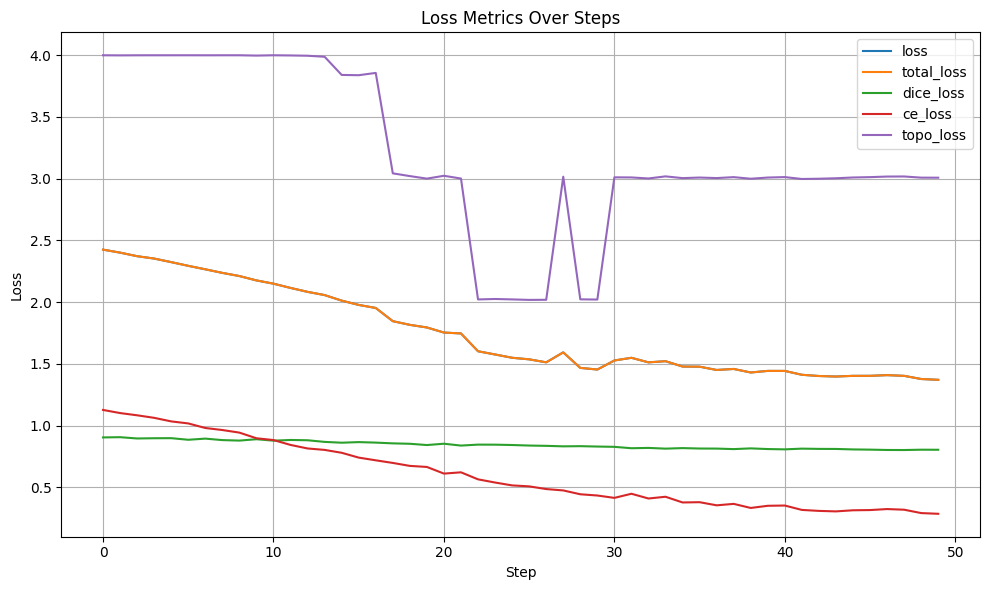

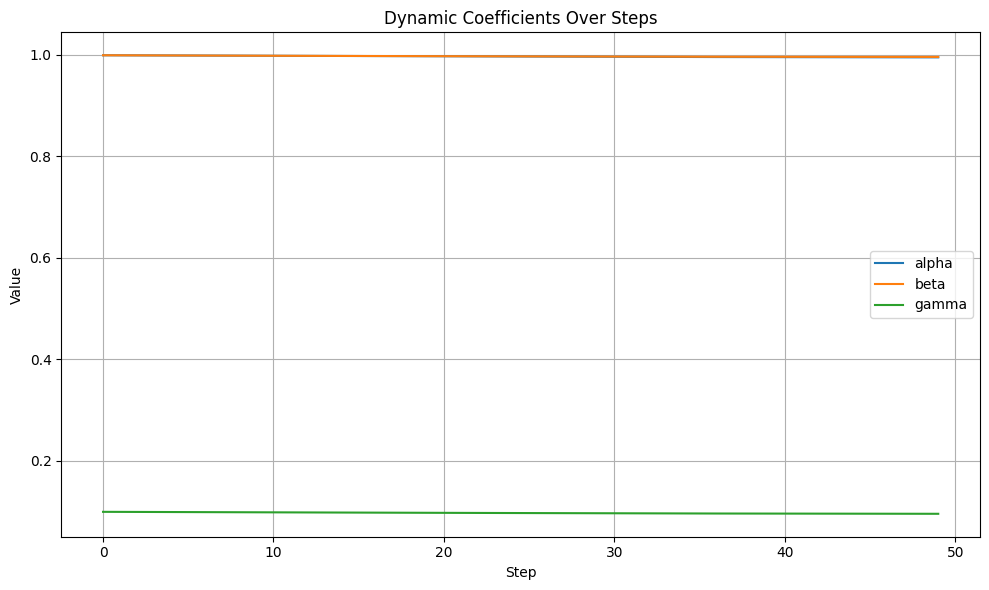

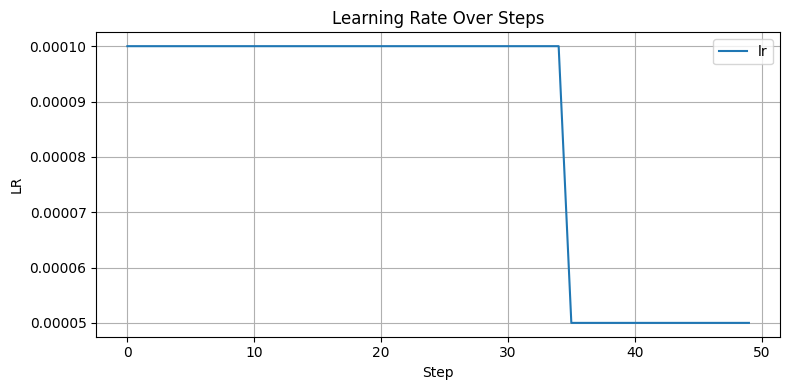

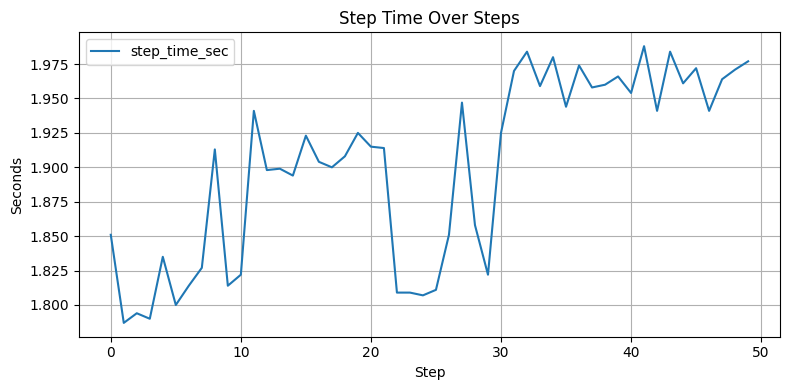

,step_time_sec,loss,lr,total_loss,dice_loss,ce_loss,topo_loss,alpha,beta,gamma
step,,,,,,,,,,
0,1.851,2.425379,0.00010,2.425379,0.904392,1.127019,3.999921,0.999001,0.999005,0.099000
1,1.787,2.401327,0.00010,2.401327,0.906331,1.101698,3.998974,0.998901,0.998907,0.098900
2,1.794,2.372344,0.00010,2.372344,0.895918,1.083617,3.999730,0.998801,0.998810,0.098800
3,1.790,2.353175,0.00010,2.353175,0.897830,1.063089,3.999911,0.998702,0.998712,0.098700
4,1.835,2.324311,0.00010,2.324311,0.898378,1.034232,3.999889,0.998602,0.998615,0.098600
5,1.800,2.294300,0.00010,2.294300,0.885387,1.017751,3.999957,0.998502,0.998519,0.098500
6,1.814,2.266135,0.00010,2.266135,0.894737,0.980802,3.999714,0.998403,0.998423,0.098400
7,1.827,2.237144,0.00010,2.237144,0.882705,0.964358,3.999925,0.998303,0.998328,0.098300
8,1.913,2.211593,0.00010,2.211593,0.878697,0.943347,3.999944,0.998204,0.998233,0.098200


In [4]:
plot_training_metrics(metrics)